In [1]:
import pandas as pd

main_df = pd.read_csv("owid_climate_data.csv")
main_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26182 entries, 0 to 26181
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country Name                26182 non-null  str    
 1   Country Code                22895 non-null  str    
 2   Year                        26182 non-null  int64  
 3   CO2 Emissions Per Capita    26182 non-null  float64
 4   Annual Temperature Anomaly  14319 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1022.9 KB


In [2]:
#Step 1.1 Inspecting if there are any NaN or missing values in the dataset before cleaning.
print("\nMissing values per column:")
print(main_df.isnull().sum()) 
print("\nThe percentage of values missing:")
print(main_df.isnull().mean() * 100)



Missing values per column:
Country Name                      0
Country Code                   3287
Year                              0
CO2 Emissions Per Capita          0
Annual Temperature Anomaly    11863
dtype: int64

The percentage of values missing:
Country Name                   0.000000
Country Code                  12.554427
Year                           0.000000
CO2 Emissions Per Capita       0.000000
Annual Temperature Anomaly    45.309755
dtype: float64


In [4]:
#Step 1.2 Cleaning the dataset
cleaned_df = (
    main_df
    .drop(columns=['Country Code']) #Drops Country Code column as it is not needed for our analyses
    .dropna(subset=['Annual Temperature Anomaly']) #Removes missing temperature rows
)
print(f"Rows before cleaning: {len(main_df)}")
print(f"Rows after cleaning: {len(cleaned_df)}")
print(f"Rows removed: {len(main_df) - len(cleaned_df)}")
print("\n")
print(cleaned_df.head())
#Saving cleaned dataset to CSV
cleaned_df.to_csv('cleaned_owid_climate_data.csv', index=False)
print("\n")
print('Cleaned dataset saved as cleaned_owid_climate_data.csv')



Rows before cleaning: 26182
Rows after cleaning: 14319
Rows removed: 11863


  Country Name  Year  CO2 Emissions Per Capita  Annual Temperature Anomaly
0  Afghanistan  1949                  0.001992                   -2.020418
1  Afghanistan  1950                  0.010837                   -2.298886
2  Afghanistan  1951                  0.011625                   -1.287201
3  Afghanistan  1952                  0.011468                   -1.237078
4  Afghanistan  1953                  0.013123                   -1.084867


Cleaned dataset saved as cleaned_owid_climate_data.csv


In [5]:
#Step 1 Creating a Set
countries_set = set(cleaned_df["Country Name"]) #Automatically removes duplicates
print(countries_set)
print(f"\nTotal unique countries: {len(countries_set)} vs Total countries with duplicates: {len(cleaned_df['Country Name'])}")



{'Kiribati', 'Australia', 'Haiti', 'Azerbaijan', 'Italy', 'Guinea', 'Moldova', 'Lithuania', 'Yemen', 'Bangladesh', 'Kazakhstan', 'Norway', 'Saudi Arabia', 'Portugal', 'United States', "Cote d'Ivoire", 'Ethiopia', 'Turkmenistan', 'Vanuatu', 'Argentina', 'Turkey', 'Brazil', 'Democratic Republic of Congo', 'Malawi', 'France', 'Fiji', 'Zambia', 'South Sudan', 'South Africa', 'Vietnam', 'Mexico', 'Laos', 'Iran', 'Djibouti', 'Kenya', 'North Korea', 'Senegal', 'Namibia', 'Finland', 'China', 'Georgia', 'Libya', 'Papua New Guinea', 'Cambodia', 'Nicaragua', 'Ghana', 'Sierra Leone', 'Mozambique', 'Trinidad and Tobago', 'Croatia', 'New Zealand', 'Bulgaria', 'Algeria', 'United Arab Emirates', 'Kuwait', 'Sudan', 'Sweden', 'Myanmar', 'Faroe Islands', 'Kyrgyzstan', 'Jamaica', 'Russia', 'Bolivia', 'Bhutan', 'Comoros', 'Estonia', 'Rwanda', 'Saint Helena', 'Bahamas', 'Egypt', 'Lebanon', 'Kosovo', 'Uruguay', 'Spain', 'Latvia', 'Palestine', 'Eritrea', 'Philippines', 'Dominican Republic', 'Guyana', 'Albania

In [6]:
def get_country_data(df, country, start_year, end_year):
    """
    Returns a filtered DataFrame for a given country and year range.

    Parameters: 
    df: any Dataframe
    country: Country name as str
    start_year: Start of year range (inclusive, int)
    end_year: End of year range (inclusive, int)
    """
    if country not in countries_set: #Validates if country exists before filtering
        print(f"'{country}' is not found in the dataset. Please check spelling or print out countries_set to check unique countries.")
        return None 
        
    filtered_country_df = df[
        (df['Country Name'] == country) &
        (df['Year'] >= start_year) &
        (df['Year'] <= end_year)
        ]
    return filtered_country_df.reset_index(drop=True)

india_data = get_country_data(cleaned_df, 'India', 2000, 2020)
print(india_data)



   Country Name  Year  CO2 Emissions Per Capita  Annual Temperature Anomaly
0         India  2000                  0.932435                   -0.224110
1         India  2001                  0.928220                   -0.147684
2         India  2002                  0.940360                    0.215657
3         India  2003                  0.956066                   -0.042418
4         India  2004                  0.998095                    0.001837
5         India  2005                  1.034569                   -0.076595
6         India  2006                  1.101976                    0.174562
7         India  2007                  1.169509                    0.052127
8         India  2008                  1.233049                   -0.179187
9         India  2009                  1.315532                    0.537815
10        India  2010                  1.348904                    0.492528
11        India  2011                  1.399205                   -0.155027
12        In

In [8]:
global_avg_co2_2020 = cleaned_df[cleaned_df['Year'] == 2020]['CO2 Emissions Per Capita'].mean()
print(f"Global average CO2 emissions per capita in 2020: {global_avg_co2_2020:.2f} metric tonnes")



Global average CO2 emissions per capita in 2020: 4.34 metric tonnes


In [9]:
#Step 2  Filtering countries where CO2 emissions are above 10 metric tons in 2020
countries_co2_above_10_2020 = cleaned_df[
    (cleaned_df['Year'] == 2020) &
    (cleaned_df['CO2 Emissions Per Capita'] > 10)
    ].reset_index(drop=True).sort_values('CO2 Emissions Per Capita', ascending=False) #From highest emitters to lowest
print(countries_co2_above_10_2020)

            Country Name  Year  CO2 Emissions Per Capita  \
11                 Qatar  2020                 36.564110   
1                Bahrain  2020                 25.215979   
2                 Brunei  2020                 24.939121   
15   Trinidad and Tobago  2020                 23.677786   
16  United Arab Emirates  2020                 23.006842   
6                 Kuwait  2020                 21.739220   
13          Saudi Arabia  2020                 19.879406   
9          New Caledonia  2020                 17.981370   
0              Australia  2020                 15.506062   
10                  Oman  2020                 15.174401   
4          Faroe Islands  2020                 14.426020   
17         United States  2020                 13.889589   
3                 Canada  2020                 13.795024   
5             Kazakhstan  2020                 13.113933   
7             Luxembourg  2020                 12.806264   
14           South Korea  2020          

In [10]:
#Step 1 Calculating the percentage of recorded observations that exceed the 1.5% Paris Threshold
paris_threshold = 1.5

#Step 2 The % of the recorded observations exceed this threshold
exceeding = cleaned_df[cleaned_df['Annual Temperature Anomaly'] > paris_threshold]
probability = (len(exceeding)) / (len(cleaned_df)) * 100

print(f"Rows exceeding 1.5 degrees: {len(exceeding)}")
print(f"Total rows in dataset: {len(cleaned_df)}")
print(f"Probability of temperature anomaly exceeding {paris_threshold}°C: {probability:.2f}%")


Rows exceeding 1.5 degrees: 49
Total rows in dataset: 14319
Probability of temperature anomaly exceeding 1.5°C: 0.34%


In [11]:
aggregated_temp_per_year = (
    cleaned_df.groupby(['Year'])['Annual Temperature Anomaly'].agg(["mean", "min", "max"]))
print(aggregated_temp_per_year)


          mean       min       max
Year                              
1940 -1.624415 -3.825056  0.423903
1941 -1.251653 -3.941369  1.779448
1942 -1.368997 -3.628582  0.683115
1943 -1.021218 -2.985201  1.080043
1944 -1.000902 -2.997106  0.915558
...        ...       ...       ...
2019  0.601391 -0.226331  1.697816
2020  0.580830 -0.231912  2.247584
2021  0.411804 -0.655329  1.511456
2022  0.444629 -0.582847  1.773571
2023  0.862665 -0.266950  1.894608

[84 rows x 3 columns]


In [12]:
#Step 5 Individual counts of unique countries & years
print("Unique countries:", cleaned_df["Country Name"].nunique())
print("Unique years:", cleaned_df["Year"].nunique())


Unique countries: 187
Unique years: 84


In [14]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch


In [15]:
#Step 6.2  Building the network graph using the 187 countries and their CO2 emissions values
G_all_countries = nx.Graph()
for _, row in cleaned_df.iterrows(): #Adding each country as a node
    G_all_countries.add_node(row['Country Name'],
               co2=row['CO2 Emissions Per Capita']) 

countries = list(cleaned_df['Country Name']) #Lists are faster to loop through than a DataFrame
co2_vals = list(cleaned_df['CO2 Emissions Per Capita'])

for i in range(len(countries)):                        # Outer loop: each country once
    for j in range(i + 1, len(countries)):             # Inner loop: only countries AFTER i
        # i + 1 means never compare a country to itself, and never repeat a pair
        if abs(co2_vals[i] - co2_vals[j]) < 1.0:      #Draw edges between countries if CO2 emissions differ by less than 1.0 metric tonne
            G_all_countries.add_edge(countries[i], countries[j])     # Connect similar countries


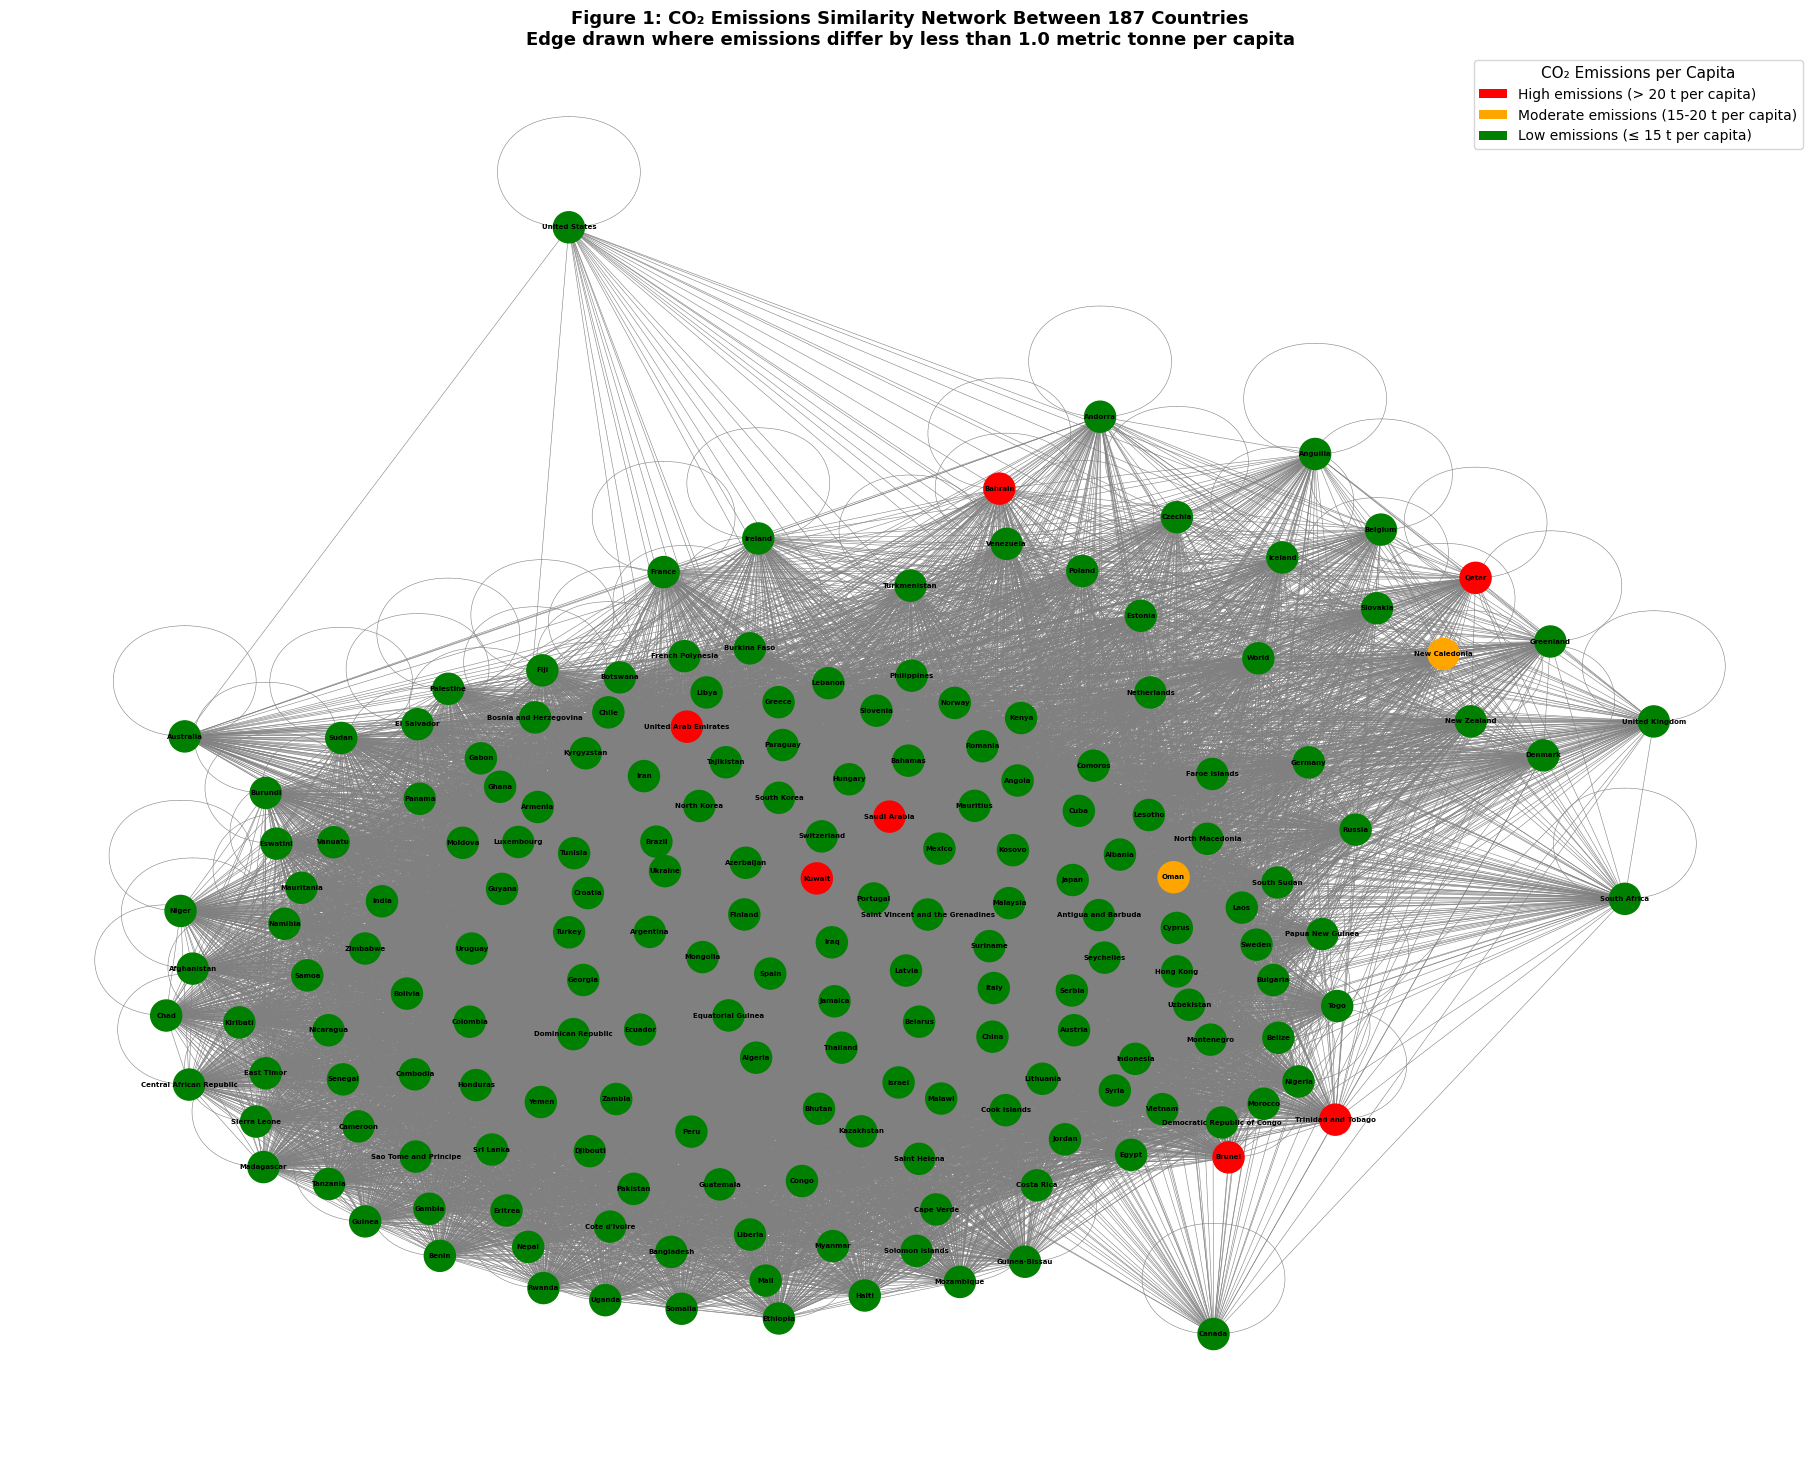

Number of nodes (countries): 187
Number of edges (similar pairs): 15456
Isolated nodes (no similar peers): 0


In [17]:
#Step 6.3 Visualising the network graph
plt.figure(figsize=(18, 14))
pos = nx.spring_layout(G_all_countries, seed=42, k=0.8)

node_colours = [
    'red'    if G_all_countries.nodes[node]['co2'] > 20
    else 'orange' if G_all_countries.nodes[node]['co2'] > 15
    else 'green'
    for node in G_all_countries.nodes
]

nx.draw(G_all_countries, pos, with_labels=True, node_color=node_colours,
        node_size=500,   # Played around with sizes for a bit, this one is the least visually cluttering size
        font_size=5,     # Reduced -- 187 labels at size 8 overlap in a unreadable and ugly way
        font_weight='bold', edge_color='grey',
        width=0.4,       # Thinner -- hundreds of edges at width 1.5 looks like a solid black blob
        )

# Legend -- explains node colour thresholds for CO₂ emissions per capita
legend = [
    Patch(facecolor='red',label='High emissions (> 20 t per capita)'),
    Patch(facecolor='orange',label='Moderate emissions (15-20 t per capita)'),
    Patch(facecolor='green',label='Low emissions (≤ 15 t per capita)'),
]
plt.legend(handles=legend, loc='upper right', fontsize=10,
           title='CO₂ Emissions per Capita', title_fontsize=11)

plt.title('Figure 1: CO₂ Emissions Similarity Network Between 187 Countries\n'
          'Edge drawn where emissions differ by less than 1.0 metric tonne per capita',
          fontsize=13, fontweight='bold')
plt.savefig('fig1_full_network_graph.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Number of nodes (countries): {G_all_countries.number_of_nodes()}")
print(f"Number of edges (similar pairs): {G_all_countries.number_of_edges()}")
print(f"Isolated nodes (no similar peers): {len(list(nx.isolates(G_all_countries)))}")

In [18]:
average_global_temp_by_year = cleaned_df.groupby('Year')['Annual Temperature Anomaly'].mean().reset_index()


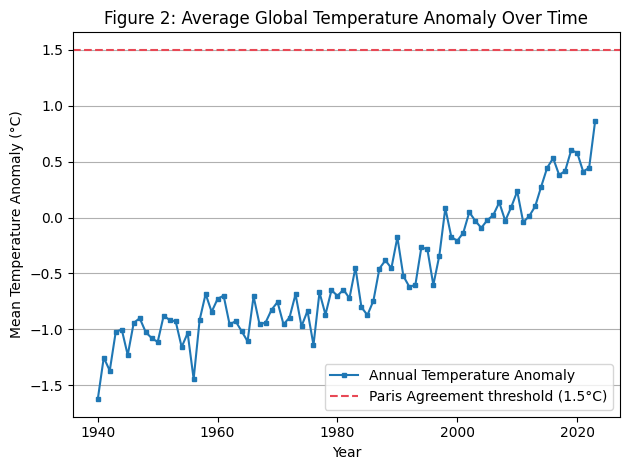

In [19]:
#Step 7.1 Line Chart of Average Temperature over Time
average_global_temp_by_year.set_index('Year')['Annual Temperature Anomaly'].plot(kind='line', marker='s', markersize='3')
plt.title('Figure 2: Average Global Temperature Anomaly Over Time')
plt.xlabel('Year')
plt.ylabel('Mean Temperature Anomaly (°C)')
plt.grid(axis='y')
plt.axhline(y=1.5, color='#E84855', linestyle='--', 
            linewidth=1.5, label='Paris Agreement threshold (1.5°C)') #Adds a horizontal line at the threshold value of 1.5. Used as a comparison.
plt.legend()
plt.tight_layout()
plt.savefig('fig2_line_temp_trend.png', dpi=150, bbox_inches='tight') 
plt.show()



In [22]:
country_co2_2020 = (
    cleaned_df[cleaned_df['Year'] == 2020]
    .groupby('Country Name')['CO2 Emissions Per Capita']
    .mean()  
    .sort_values(ascending=True) #Ascending for better readability
    .reset_index()
)

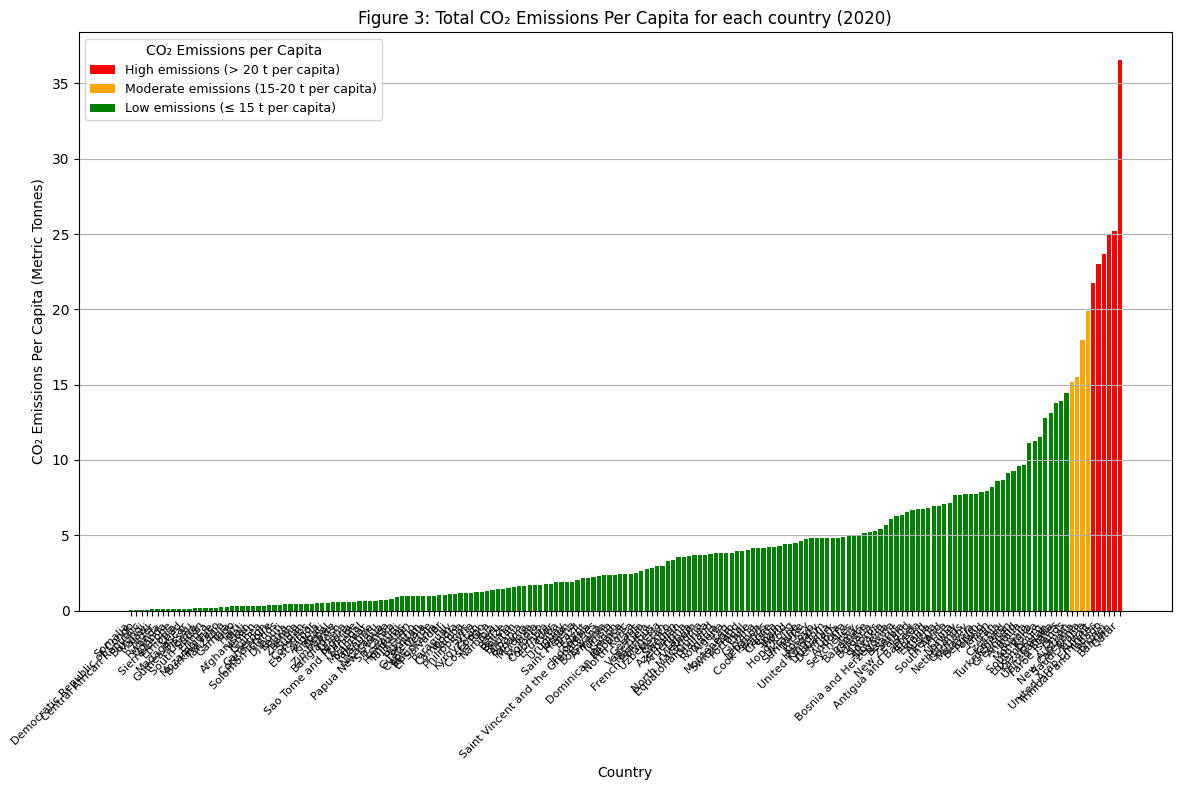

In [23]:
# Step 7.3.1 Creating the bar chart
# Colour coded to match network graph from Step 6 -- red above 20t, orange 15-20t, green 10-15t
colours = ['red' if v > 20 
           else 'orange' if v > 15 
           else 'green' 
           for v in country_co2_2020['CO2 Emissions Per Capita']]
plt.figure(figsize=(12, 8))
plt.bar(country_co2_2020['Country Name'], country_co2_2020['CO2 Emissions Per Capita'], color=colours)
plt.title('Figure 3: Total CO₂ Emissions Per Capita for each country (2020)')
plt.xlabel('Country')
plt.ylabel('CO₂ Emissions Per Capita (Metric Tonnes)')
plt.xticks(rotation=45, ha='right', fontsize=8)  # Angled labels so country names don't overlap
plt.grid(axis='y')

legend = [
    Patch(facecolor='red',    label='High emissions (> 20 t per capita)'),
    Patch(facecolor='orange', label='Moderate emissions (15-20 t per capita)'),
    Patch(facecolor='green',  label='Low emissions (≤ 15 t per capita)'),
]
plt.legend(handles=legend, loc='upper left', fontsize=9,
           title='CO₂ Emissions per Capita', title_fontsize=10)

plt.tight_layout()
plt.savefig('fig3_bar_co2_2020_emitters.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
#Step 7.4 Adding temperature with filtered dataframe that contains only the 2020 rows
# Reusing country_co2_2020 from Step 7.3 
temp_co2_2020 = cleaned_df[
    (cleaned_df['Year'] == 2020) &
    (cleaned_df['Country Name'].isin(country_co2_2020['Country Name']))
].reset_index(drop=True)
print(temp_co2_2020)

    Country Name  Year  CO2 Emissions Per Capita  Annual Temperature Anomaly
0    Afghanistan  2020                  0.297063                   -0.171064
1        Albania  2020                  1.640428                    0.708608
2        Algeria  2020                  3.818575                    1.017536
3        Andorra  2020                  4.926832                    0.394073
4         Angola  2020                  0.494244                    0.401648
..           ...   ...                       ...                         ...
182      Vietnam  2020                  3.695583                    0.518624
183        World  2020                  4.453724                    0.432163
184        Yemen  2020                  0.301205                    0.108743
185       Zambia  2020                  0.427315                    0.137313
186     Zimbabwe  2020                  0.547085                    0.229293

[187 rows x 4 columns]


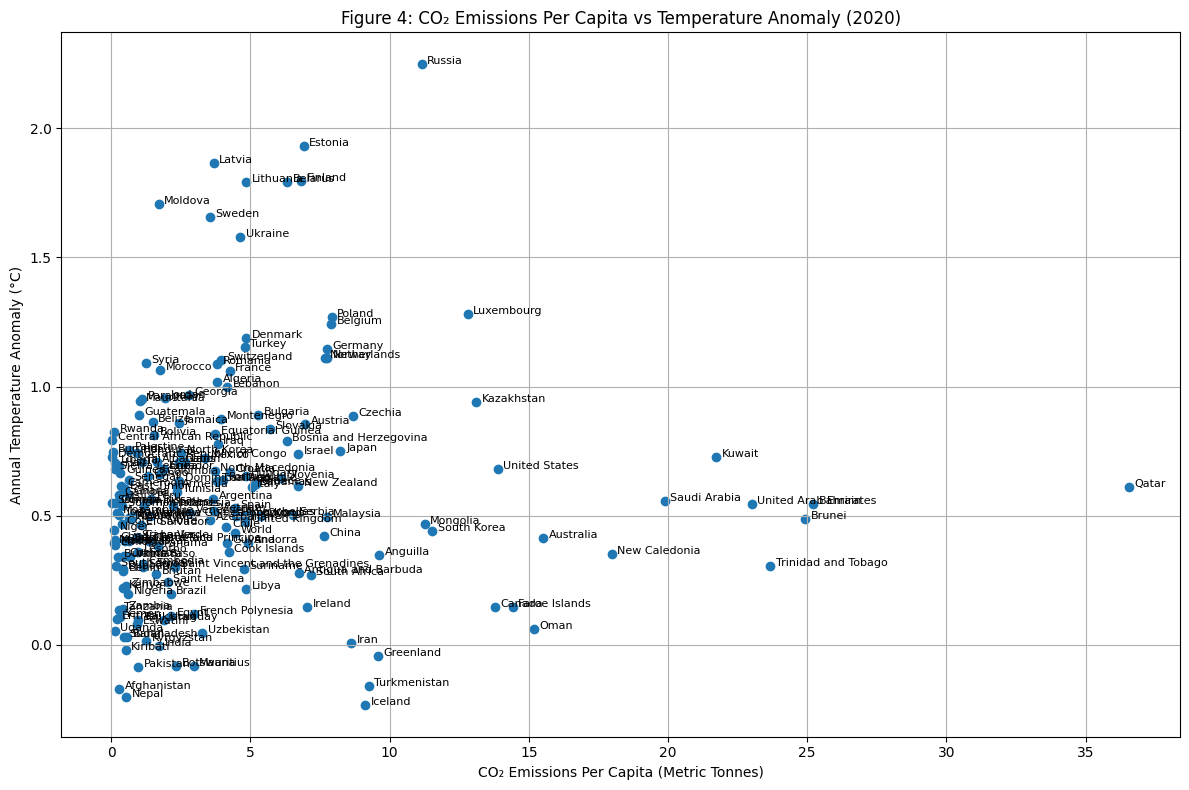

In [27]:
plt.figure(figsize=(12, 8))
plt.scatter(temp_co2_2020['CO2 Emissions Per Capita'],
            temp_co2_2020['Annual Temperature Anomaly'],
            )
# Labelling each country point directly
for _, row in temp_co2_2020.iterrows():
    plt.text(row['CO2 Emissions Per Capita'] + 0.2, #Added 0.2 so it's slightly off to the side and not directly atop the coloured dots
             row['Annual Temperature Anomaly'],
             row['Country Name'], fontsize=8)
plt.title('Figure 4: CO₂ Emissions Per Capita vs Temperature Anomaly (2020)')
plt.xlabel('CO₂ Emissions Per Capita (Metric Tonnes)')
plt.ylabel('Annual Temperature Anomaly (°C)')
plt.grid(True)

plt.tight_layout()
plt.savefig('fig4_scatter_co2_temp.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
exceeding = cleaned_df[cleaned_df['Annual Temperature Anomaly'] > paris_threshold]
probability = (len(exceeding)) / (len(cleaned_df)) * 100

print(exceeding)
print(f"Rows exceeding 1.5 degrees: {len(exceeding)}")
print(f"Total rows in dataset: {len(cleaned_df)}")
print(f"Probability of temperature anomaly exceeding {paris_threshold}°C: {probability:.2f}%")


                 Country Name  Year  CO2 Emissions Per Capita  \
411                   Algeria  2021                  4.012335   
446                   Andorra  2022                  5.265905   
447                   Andorra  2023                  5.244343   
956                   Armenia  2010                  1.450935   
964                   Armenia  2018                  2.000838   
969                   Armenia  2023                  2.584923   
2097               Azerbaijan  2010                  3.011876   
2110               Azerbaijan  2023                  4.258217   
2606                  Belarus  2019                  6.581234   
2607                  Belarus  2020                  6.315496   
3418   Bosnia and Herzegovina  2023                  6.335610   
3934                 Bulgaria  2023                  5.311196   
4437                   Canada  2010                 16.221796   
4450                   Canada  2023                 13.977411   
7015                    E